Emmaus

I will probably plot two or three graphs for this, one based on just on the unblindedReadNodule level and the other will be based on the median malignancy ratings. I will use the existing csv files because running through the XML files all over again is probably inefficient. Last one could possible be based on soft labels

UnblindedReadNodule level

Looked through 0 slices
Looked through 200 slices
Looked through 300 slices
Looked through 700 slices
Looked through 1800 slices
Looked through 1900 slices
Looked through 2300 slices
Looked through 2600 slices
Looked through 4800 slices
Looked through 5900 slices
Looked through 6100 slices
Looked through 7100 slices
Looked through 7400 slices
Looked through 8000 slices
Looked through 8100 slices
Looked through 8200 slices
Looked through 8400 slices
Looked through 9400 slices
Looked through 10300 slices
Looked through 10800 slices
Looked through 11200 slices
Looked through 11400 slices
Looked through 11900 slices
Looked through 12600 slices
Looked through 12900 slices
Looked through 13600 slices
Looked through 13800 slices
Looked through 14700 slices
Looked through 14800 slices
Looked through 15400 slices
Looked through 16300 slices
Looked through 16400 slices
Looked through 17800 slices
Looked through 19200 slices
Looked through 19500 slices
Looked through 19800 slices
Looked through 2

([<matplotlib.axis.XTick at 0x1180e2e90>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

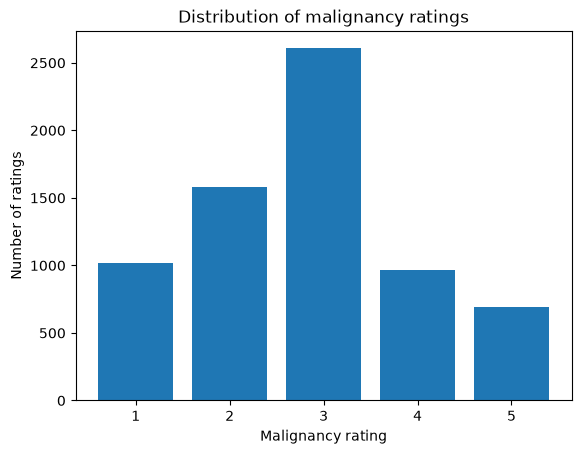

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

project_folder = Path(os.getcwd()).parent
labels_roi_path = project_folder / "data" / "labels_roi.csv"
df = pd.read_csv(labels_roi_path)
malignancy_ratings = []
slices_ran_through = []

for index, row in df.iterrows():
    series_instance_uid = row["series_instance_uid"]
    nodule_id = row["nodule_id"]
    nodule_slice = [series_instance_uid, nodule_id]
    if nodule_slice in slices_ran_through:
        continue
    else:
        malignancy = int(row["malignancy"]) # Integer in this case because it is only 12345
        malignancy_ratings.append(malignancy)
        slices_ran_through.append(nodule_slice)
    
    if index % 100 == 0:
        print("Looked through", index, "slices")

counts = Counter(malignancy_ratings)

ratings = [1, 2, 3, 4, 5]
frequencies = [counts[rating] for rating in ratings]

plt.bar(ratings, frequencies)

plt.xlabel("Malignancy rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of malignancy ratings")

plt.xticks(ratings)

Distribution of median malignancy ratings (hard labels)

Looked through 0 nodules
Looked through 100 nodules
Looked through 200 nodules
Looked through 300 nodules
Looked through 400 nodules
Looked through 500 nodules
Looked through 600 nodules
Looked through 700 nodules
Looked through 800 nodules
Looked through 900 nodules
Looked through 1000 nodules
Looked through 1100 nodules
Looked through 1200 nodules
Looked through 1300 nodules
Looked through 1400 nodules
Looked through 1500 nodules
Looked through 1600 nodules
Looked through 1700 nodules
Looked through 1800 nodules

Number of nodules for each malignancy rating:
Rating 1: 206 nodules
Rating 2: 288 nodules
Rating 3: 898 nodules
Rating 4: 316 nodules
Rating 5: 177 nodules


([<matplotlib.axis.XTick at 0x11809d210>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

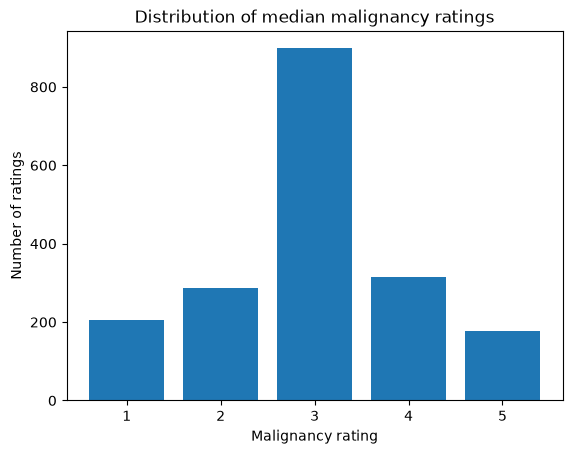

In [3]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

project_folder = Path(os.getcwd()).parent
nodules_labels_path = project_folder / "data" / "nodules_labels.csv"
df = pd.read_csv(nodules_labels_path)
malignancy_ratings = []

for index, row in df.iterrows():
    malignancy = int(row["hard"]) # Integer in this case because it is only 12345
    malignancy_ratings.append(malignancy)
    
    if index % 100 == 0:
        print("Looked through", index, "nodules")

counts = Counter(malignancy_ratings)

ratings = [1, 2, 3, 4, 5]
frequencies = [counts[rating] for rating in ratings]

print("\nNumber of nodules for each malignancy rating:")

for rating, frequency in zip(ratings, frequencies):
    print(f"Rating {rating}: {frequency} nodules")

plt.bar(ratings, frequencies)

plt.xlabel("Malignancy rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of median malignancy ratings")

plt.xticks(ratings)

Visualise distrubution of train/test/val sets


Training set:
Rating 1: 139 nodules
Rating 2: 195 nodules
Rating 3: 623 nodules
Rating 4: 222 nodules
Rating 5: 126 nodules

Validation set:
Rating 1: 30 nodules
Rating 2: 47 nodules
Rating 3: 139 nodules
Rating 4: 50 nodules
Rating 5: 24 nodules

Test set:
Rating 1: 37 nodules
Rating 2: 46 nodules
Rating 3: 136 nodules
Rating 4: 44 nodules
Rating 5: 27 nodules


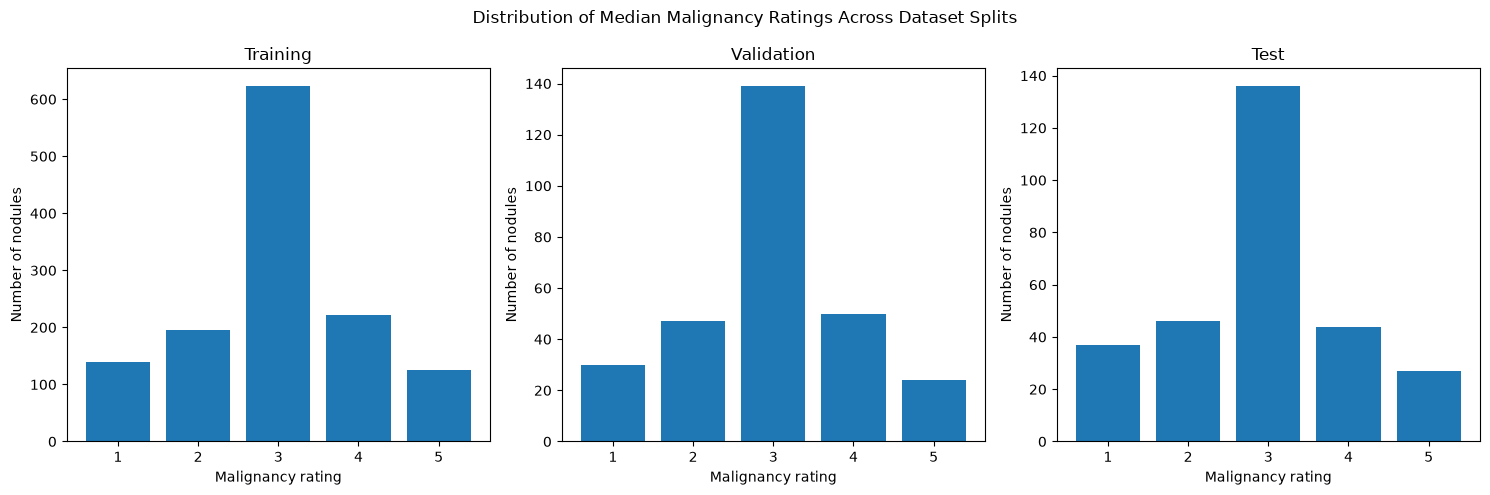

In [4]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

project_folder = Path(os.getcwd()).parent
nodules_labels_path = project_folder / "data" / "nodules_labels.csv"

df = pd.read_csv(nodules_labels_path)

ratings = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [
    ("train", "Training"),
    ("val", "Validation"),
    ("test", "Test")
]

for ax, (split_name, title) in zip(axes, splits):
    split_df = df[df["split"] == split_name]
    malignancy_ratings = split_df["hard"].astype(int)
    counts = Counter(malignancy_ratings)
    frequencies = [counts[rating] for rating in ratings]
    
    print(f"\n{title} set:")
    for rating, frequency in zip(ratings, frequencies):
        print(f"Rating {rating}: {frequency} nodules")

    ax.bar(ratings, frequencies)
    ax.set_xlabel("Malignancy rating")
    ax.set_ylabel("Number of nodules")
    ax.set_title(title)
    ax.set_xticks(ratings)

plt.suptitle("Distribution of Median Malignancy Ratings Across Dataset Splits")
plt.tight_layout()

Training weights for model A

In [5]:
train_df = df[df["split"] == "train"]
train_malignancy_ratings = train_df["hard"].astype(int)
train_counts = Counter(train_malignancy_ratings)

N = len(train_df)
K = 5

weights = []

for rating in ratings:
    n_i = train_counts[rating]
    weight = N / (K * n_i)

    weights.append({
        "malignancy_rating": rating,
        "no_of_nodules": n_i,
        "class_weight": weight
    })

weights_df = pd.DataFrame(weights)

print("Class weights:")
print(weights_df)

weights_path = project_folder / "data" / "train_weights_a.csv"
weights_df.to_csv(weights_path, index=False)

print(f"Saved to: {weights_path}")

Class weights:
   malignancy_rating  no_of_nodules  class_weight
0                  1            139      1.877698
1                  2            195      1.338462
2                  3            623      0.418941
3                  4            222      1.175676
4                  5            126      2.071429
Saved to: /Users/emmaussim/Desktop/School things/IDP/05 Capstone Project/Actual Project/Python Project/Classifying-malignancy-in-lung-nodules-using-deep-learning-models/data/train_weights_a.csv


Distribution of soft labels

Looked through 0 nodules
Looked through 100 nodules
Looked through 200 nodules
Looked through 300 nodules
Looked through 400 nodules
Looked through 500 nodules
Looked through 600 nodules
Looked through 700 nodules
Looked through 800 nodules
Looked through 900 nodules
Looked through 1000 nodules
Looked through 1100 nodules
Looked through 1200 nodules
Looked through 1300 nodules
Looked through 1400 nodules
Looked through 1500 nodules
Looked through 1600 nodules
Looked through 1700 nodules
Looked through 1800 nodules

Average probability for each malignancy rating:
Rating 1: 0.15225464190981433
Rating 2: 0.22687886825817857
Rating 3: 0.384526967285588
Rating 4: 0.1382404951370469
Rating 5: 0.09809902740937224


(0.0, 1.0)

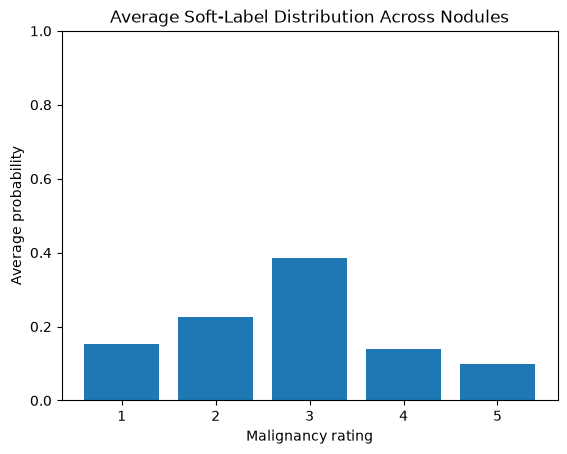

In [6]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_folder = Path(os.getcwd()).parent
nodules_labels_path = project_folder / "data" / "nodules_labels.csv"
df = pd.read_csv(nodules_labels_path)

soft_labels = []

for index, row in df.iterrows():
    probabilities = [
        row["soft_1"],
        row["soft_2"],
        row["soft_3"],
        row["soft_4"],
        row["soft_5"]
    ]

    soft_labels.append(probabilities)

    if index % 100 == 0:
        print("Looked through", index, "nodules")

average_probabilities = df[
    ["soft_1", "soft_2", "soft_3", "soft_4", "soft_5"]
].mean()

ratings = [1, 2, 3, 4, 5]
probabilities = average_probabilities.tolist()

print("\nAverage probability for each malignancy rating:")
for rating, probability in zip(ratings, probabilities):
    print(f"Rating {rating}: {probability}")

plt.bar(ratings, probabilities)

plt.xlabel("Malignancy rating")
plt.ylabel("Average probability")
plt.title("Average Soft-Label Distribution Across Nodules")

plt.xticks(ratings)
plt.ylim(0, 1)

Distribution of train/test/val sets (soft labels)


Training set:
Rating 1: 0.1528735632183908
Rating 2: 0.21724137931034482
Rating 3: 0.389463601532567
Rating 4: 0.1379948914431673
Rating 5: 0.10242656449553

Validation set:
Rating 1: 0.14741379310344827
Rating 2: 0.24281609195402296
Rating 3: 0.38247126436781603
Rating 4: 0.139367816091954
Rating 5: 0.08793103448275862

Test set:
Rating 1: 0.1543103448275862
Rating 2: 0.2543103448275862
Rating 3: 0.364367816091954
Rating 4: 0.1382183908045977
Rating 5: 0.08879310344827586


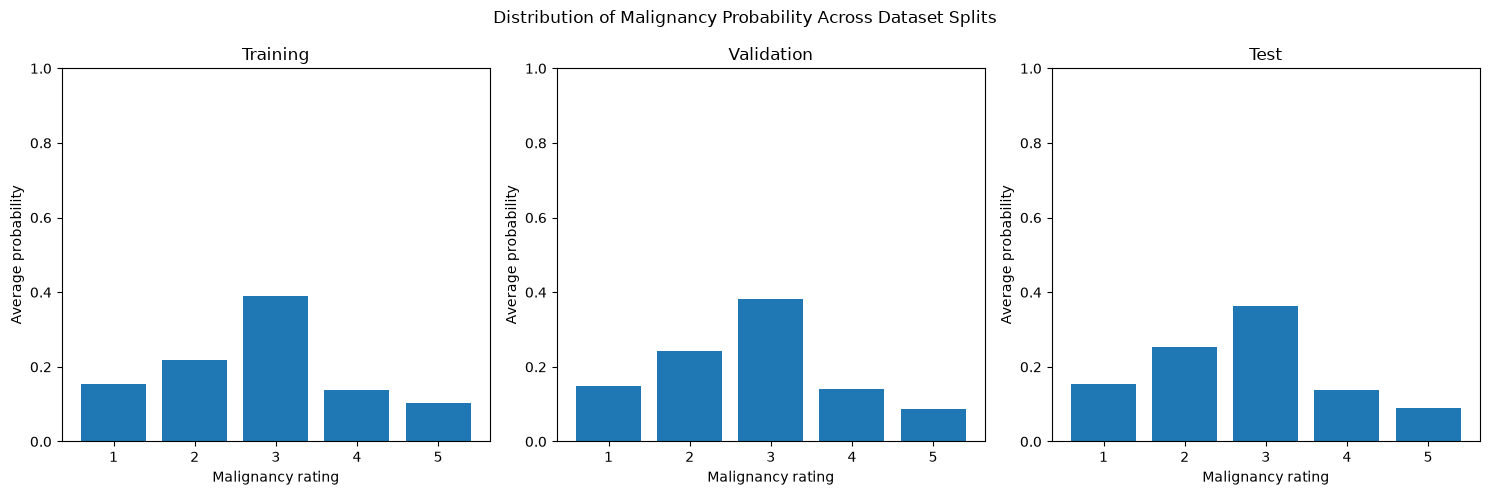

In [7]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

project_folder = Path(os.getcwd()).parent
nodules_labels_path = project_folder / "data" / "nodules_labels.csv"

df = pd.read_csv(nodules_labels_path)
ratings = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [
    ("train", "Training"),
    ("val", "Validation"),
    ("test", "Test")
]

for ax, (split_name, title) in zip(axes, splits):
    split_df = df[df["split"] == split_name]

    soft_labels = []

    average_probabilities = split_df[
        ["soft_1", "soft_2", "soft_3", "soft_4", "soft_5"]
    ].mean()
    probabilities = average_probabilities.tolist()
    
    print(f"\n{title} set:")
    for rating, probability in zip(ratings, probabilities):
        print(f"Rating {rating}: {probability}")

    ax.bar(ratings, probabilities)
    ax.set_xlabel("Malignancy rating")
    ax.set_ylabel("Average probability")
    ax.set_title(title)
    ax.set_xticks(ratings)
    ax.set_ylim(0, 1)

plt.suptitle("Distribution of Malignancy Probability Across Dataset Splits")
plt.tight_layout()

Ok I just realised that it is the same throughout because these are probability distributions

Training weights for model b

In [8]:
train_df = df[df["split"] == "train"]

average_probabilities = train_df[
    ["soft_1", "soft_2", "soft_3", "soft_4", "soft_5"]
].mean()
probabilities = average_probabilities.tolist()

N = 1
K = 5

weights = []

for rating in ratings:
    average_probability = probabilities[rating - 1]    
    weight = N / (K * average_probability)

    weights.append({
        "malignancy_rating": rating,
        "average_probability": average_probability,
        "class_weight": weight
    })

weights_df = pd.DataFrame(weights)

print("Class weights:")
print(weights_df)

weights_path = project_folder / "data" / "train_weights_b.csv"
weights_df.to_csv(weights_path, index=False)

print(f"Saved to: {weights_path}")

Class weights:
   malignancy_rating  average_probability  class_weight
0                  1             0.152874      1.308271
1                  2             0.217241      0.920635
2                  3             0.389464      0.513527
3                  4             0.137995      1.449329
4                  5             0.102427      1.952618
Saved to: /Users/emmaussim/Desktop/School things/IDP/05 Capstone Project/Actual Project/Python Project/Classifying-malignancy-in-lung-nodules-using-deep-learning-models/data/train_weights_b.csv
